In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:

def vegards_law(
    a_A,
    a_B,
    x,
    b=None
):
    """
    Interpolate between materials
    Lattice constant calculator

    https://en.wikipedia.org/wiki/Vegard%27s_law
    a_(A_(1-x)B_x) = (1-x) a_A + x a_B

    Use b for bandgap bowing parameter
    """
    if b is None:
        return (1-x) * a_A + x * a_B
    else:
        return (1-x) * a_A + x * a_B - b * x * (1 - x)

def plot_bandgap_lattice_constant(
    alloys=None,
    semiconductor_data='../data/semiconductors.csv',
    ax=None,
):
    """
    PLot semiconductor bandgaps vs lattice constants
    
    Use vegards_law to interpolate alloys with 
    Vurgaftman 2001
    Band parameters for III-V compound semiconductors and their alloys
    """
    df = pd.read_csv(semiconductor_data)
    df['Bandgap (Eg)'] = df['Bandgap (Eg)'].str.replace(' eV', '').astype(float)

    color_dict = {
        'Diamond (FCC)': 'red',
        'Zinc blende (FCC)': 'blue',
        'Wurtzite': 'green',
    }
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    for structure, color in color_dict.items():
        subset = df[df['Crystal Structure'] == structure]
        ax.scatter(
            subset['a (A)'],
            subset['Bandgap (Eg)'],
            color=color,
            s=50,
            label=structure
        )

    for _, row in df.iterrows():
        ax.annotate(
            row['Material'],
            (row['a (A)'], row['Bandgap (Eg)']),
            textcoords="offset points",
            xytext=(0, 10)
        )

    if alloys is not None:
        # Expected format ("GaAs", "InAs", 0.5, bowing_parameter (Optional))
        # Alloy dictionary / dataclass?

        df_mat = df.set_index('Material')
        for alloy in alloys:
            comp1 = alloy[0]
            comp2 = alloy[1]
            if comp1 not in df_mat.index:
                print(f"{comp1} not in database {df_mat.index}")
            if comp2 not in df_mat.index:
                print(f"{comp2} not in database {df_mat.index}")

            if comp1 in df_mat.index and comp2 in df_mat.index:
                eg1 = df_mat.loc[comp1, 'Bandgap (Eg)']
                eg2 = df_mat.loc[comp2, 'Bandgap (Eg)']
                a1 = df_mat.loc[comp1, 'a (A)']
                a2 = df_mat.loc[comp2, 'a (A)']

                x = alloy[2]

                if len(alloy) == 4:
                    alloy_bandgap = vegards_law(eg1, eg2, x, alloy[3])
                else:
                    alloy_bandgap = vegards_law(eg1, eg2, x)

                alloy_lattice = vegards_law(a1, a2, x)

                # TODO-TD: interp dotted line? 
                # bowing parameter & x sweep?
                ax.scatter(
                    alloy_lattice,
                    alloy_bandgap,
                    c='grey',
                    s=45
                )
                alloy_name = f'({comp1}_{1-x})({comp2}_{x})'
                ax.annotate(
                    alloy_name,
                    (alloy_lattice, alloy_bandgap),
                    textcoords="offset points",
                    xytext=(0, 10)
                )

    ax.legend(title="Crystal Structure")
    plt.title('Semiconductor Bandgap vs. Lattice Constant (a)')
    plt.xlabel('Lattice Constant a (A)')
    plt.ylabel('Bandgap $E_g$ (eV)')
    plt.grid(ls='--', alpha=0.3)
    plt.tight_layout()
    return ax


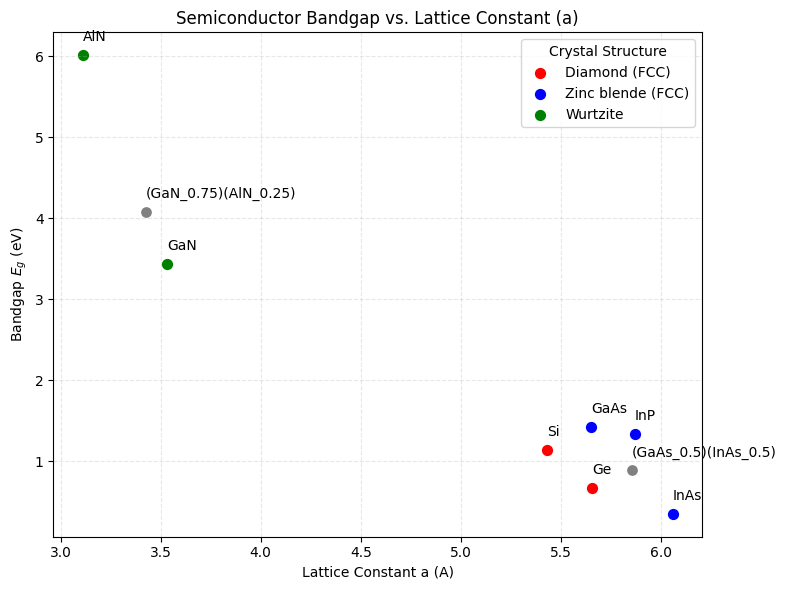

In [9]:
ax = plot_bandgap_lattice_constant(
    alloys=[
        ('GaAs', 'InAs', 0.5), 
        ('GaN', 'AlN', 0.25)
    ]
)
plt.show()